## Trend and cycle decompositions of time series data

We are going to use *Python* to perform an empirical exercise similar to the one documented in Schmitt-Grohe and Uribe (2017, Ch.1). We need first to import the necessary modules to manage data (`pandas`), compute some scientific calculations (`numpy`), do some graphs (`matplotlib.pyplot`), and perform some estimation exercises (`statsmodels,api`):

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

Let's upload our data file `Macro_data_bc_analysis.xlsx`. It contains the *log* transformations of the real GDP per capita $(y)$, consumption of non-durables and durables per capita $(c)$, exports per capita $(x)$, imports per capita $(m)$ and the trade balance per capita $(\frac{tb}{y}=\frac{(x-m)}{y})$ measured in constant prices of the local currency of six (6) countries for the period 1961-2019. In the case of $y$, there is also a measure based on constant dollars of 2015. The source of these data are the World Bank's *World Development Indicators* (WDI).

Our data management will be done by using the **Pandas** library in python. Once we upload the file using the function `read_excel()`, we immediately create an object called a *DataFrame* that we name `sample_macro_data`.

In [3]:
sample_macro_data = pd.read_excel('Macro_data_bc_analysis.xlsx')
sample_macro_data.head()

,Country Name,Year,TB.KN.PC.TO.GDP,NY.GDP.PCAP.KD,NY.GDP.PCAP.KN,CON.PRVT.KN.PC,EXP.GNFS.KN.PC,IMP.GNFS.KN.PC
0,Brazil,1961,-0.013674,7.907284,8.732146,8.178347,5.160179,5.556677
1,Brazil,1962,-0.014308,7.941519,8.766380,8.210422,5.053544,5.514882
2,Brazil,1963,-0.006491,7.918088,8.742949,8.174009,5.270990,5.460778
3,Brazil,1964,-0.005805,7.922574,8.747435,8.178509,5.096532,5.298294
4,Brazil,1965,-0.000319,7.917995,8.742856,8.160391,5.103766,5.115841


Schmitt-Grohe and Uribe (2017, Ch.1), classify countries according to the value of their annual dollar PPP converted GDP per capita. A country is considered *poor* if such value is up to $\$3000$; as an *emerging* country if it is in the range between $\$3001$ and $\$25000$; and as a *rich* if the value is above $\$25000$. Within `sample_macro_data` we have data for 6 countries:

- *Poor*: **Cameroon**, **India**
- *Emerging*: **Brazil**, **Colombia**
- *Rich*: **United Kingdom**, **United States**

Below, using the attribute of the *DataFrame* `unique()`, we identify unique values for the first column of our DataFrame `sample_macro_data`, that contains the country names, and create a *list* named `countries` containing the name of all 6 countries. Furthermore, we also create the lists `poor_countries`, `em_countries`, and `rich_countries` to classify countries according to the classification above which will be useful further below. On top of that, we also create the list `variables` that contains the names of all our variables of interest:

In [4]:
countries = sample_macro_data['Country Name'].unique()
poor_countries = ['Cameroon', 'India']
em_countries = ['Brazil', 'Colombia']
rich_countries = ['United Kingdom', 'United States']
variables = ['NY.GDP.PCAP.KD', 'NY.GDP.PCAP.KN', 'CON.PRVT.KN.PC',
             'EXP.GNFS.KN.PC', 'IMP.GNFS.KN.PC', 'TB.KN.PC.TO.GDP']

To make easier data management by country and groups of countries, let's create a *dictionary* in which any element contains the data for a single country, then we can easily extract the data for a single country from such object. First we create an *empty* dictionary with `series_dict = {}` and then a loop structure allows us to allocate each data set as a single element of the dictionary. For purposes which will be clear below we add to each country data set 3 new variables:

- A $\text{constant}$ variable which takes value equal to $1$ for each time period within the data set.
- A *linear trend* variable: $\text{trend} = {1,2,3,\ldots,T}$; $T$ being equal to the total number of years within the data set.
- A *quadratic trend* variable: $\text{trend\_squared} = \text{trend}^2$


In [5]:
series_dict = {}

for country in countries:
    bc_series = sample_macro_data[sample_macro_data['Country Name'] == 
                                  country][['Year'] + variables].set_index('Year')
    bc_series.dropna(subset = variables, inplace = True)
    
    bc_series['constant'] = 1
    
    bc_series['trend'] = range(1, len(bc_series) + 1)
    
    bc_series['trend_squared'] = bc_series['trend'] ** 2
    
    series_dict[country] = bc_series
    
series_dict['Colombia'].head()

,NY.GDP.PCAP.KD,NY.GDP.PCAP.KN,CON.PRVT.KN.PC,EXP.GNFS.KN.PC,IMP.GNFS.KN.PC,TB.KN.PC.TO.GDP,constant,trend,trend_squared
Year,,,,,,,,,
1961,7.594710,15.511073,15.252341,13.088285,12.779367,0.023566,1,1,1
1962,7.616454,15.532817,15.296149,13.135211,12.782668,0.027017,1,2,4
1963,7.618133,15.534496,15.312855,13.080113,12.750385,0.024132,1,3,9
1964,7.647713,15.564076,15.376370,13.106448,12.940938,0.013063,1,4,16
1965,7.653310,15.569673,15.325042,13.138811,12.712245,0.030545,1,5,25


As a first step, let's compare the time path of the GDP per capita in constant dollars $(y_{US}\equiv \text{NY.GDP.PCAP.KD})$ by the income classification described above. We create a *grid* of 1 $\times$ 3 subplots in which the time path of $y_{US}$ is presented for *poor*, emerging, and rich countries, respectively. For that we use the `subplot()` function of the library `matplotlib.pyplot` and loop structures to include more than one series in a single graph:

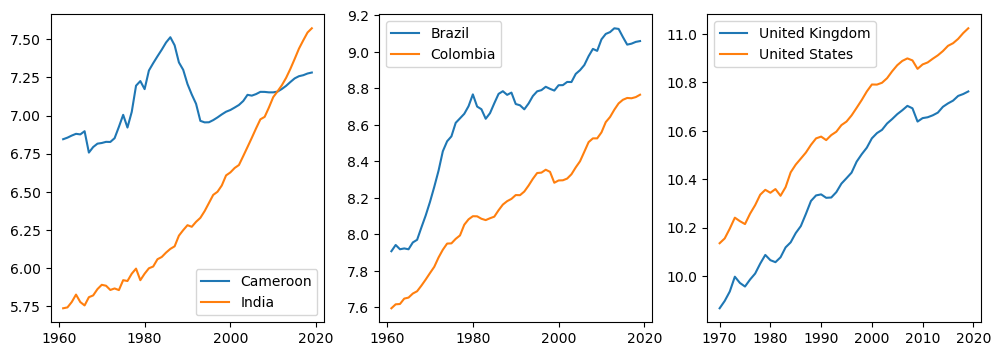

In [6]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12,4))

for poor_country in poor_countries:
    axes[0].plot(series_dict[poor_country].index,
                    series_dict[poor_country][variables[0]],
                    label = poor_country)
axes[0].legend()

for em_country in em_countries:
    axes[1].plot(series_dict[em_country].index,
                    series_dict[em_country][variables[0]],
                    label = em_country)
axes[1].legend()
    
for rich_country in rich_countries:
    axes[2].plot(series_dict[rich_country].index,
                    series_dict[rich_country][variables[0]],
                    label = rich_country)
axes[2].legend()

### General decomposition

Let $\{z_{t}\}_{t=1}^{T}$ be some time series (observations) on the value of a specific economic measure. Along the time period $t=1\ldots,T$ we can decompose the time series as:

$$ z_t = z_{t}^{c} + z_{t}^{s} $$
    
where:
    
- $z_{t}^{c}$: **cyclical component**
- $z_{t}^{s}$: (long-run trend) **secular component** 
    
Based on this general decomposition, following Schmitt-Grohe and Uribe (2017, Ch. 1), we examine two trend-cycle decompositions: *quadratic detrending* and the *Hodrick-Prescott filter*.

### Quadratic Detrending

1. Estimate the parameters of the linear regression model:

    $$ z_{t} = \theta_{0}+\theta_{1}t + \theta_{2}t^{2}+ \epsilon_{t} $$


2. Secular and cyclical components are:
    
    \begin{gather}
    \color{red}\hat{z}_{t}^{s} = \hat{\theta}_{0}+\hat{\theta}_{1}t + \hat{\theta}_{2}t^{2}\\[0.2cm]
    \color{red}\hat{z}_{t}^{c} = \hat{\epsilon}_{t} = z_{t} - z_{t}^{s}
    \end{gather}

First, let's apply quadratic detrending to our sample of variables, excluding $tb$, and countries. Using a loop structure in python which makes use of the `OLS()` function of the module `statsmodels`:

* We estimate the regression equation for each time series using as regressors the $\text{constant}$, $\text{trend}$ and $\text{trend\_squared}$ variables that are associated to the coefficients $\theta_0$, $\theta_1$ and $\theta_2$, respectively. We store the regression into an object named `quad_reg`. 

* By using the attribute `fit()` of the `quad_reg` object, we obtain the estimated equation, i.e. the estimated $\hat{\theta}_0,\;\hat{\theta}_1,\;\hat{\theta}_2$, and store them into a new object named `results`.

* The `result`'s attribute function `predict()` allows us to compute $\color{red}\hat{z}_{QD}^{s}$ as in equation (1), and then, using (2) we are able to compute $\color{red}\hat{z}_{QD}^{c}$:

In [7]:
for country in countries:
    for variable in variables:
        quad_reg = sm.OLS(endog = series_dict[country][variable],
                          exog = series_dict[country][['constant', 'trend', 'trend_squared']])
        results = quad_reg.fit()
        series_dict[country][variable + '.S_QD'] = results.predict()
        series_dict[country][variable + '.C_QD'] = series_dict[country][variable] - series_dict[country][variable + '.S_QD']
                                                
series_dict['Colombia'].head()

,NY.GDP.PCAP.KD,NY.GDP.PCAP.KN,CON.PRVT.KN.PC,EXP.GNFS.KN.PC,IMP.GNFS.KN.PC,TB.KN.PC.TO.GDP,constant,trend,trend_squared,NY.GDP.PCAP.KD.S_QD,...,NY.GDP.PCAP.KN.S_QD,NY.GDP.PCAP.KN.C_QD,CON.PRVT.KN.PC.S_QD,CON.PRVT.KN.PC.C_QD,EXP.GNFS.KN.PC.S_QD,EXP.GNFS.KN.PC.C_QD,IMP.GNFS.KN.PC.S_QD,IMP.GNFS.KN.PC.C_QD,TB.KN.PC.TO.GDP.S_QD,TB.KN.PC.TO.GDP.C_QD
Year,,,,,,,,,,,,,,,,,,,,,
1961,7.594710,15.511073,15.252341,13.088285,12.779367,0.023566,1,1,1,7.618002,...,15.534365,-0.023292,15.326587,-0.074246,12.968924,0.119361,12.789985,-0.010618,0.004371,0.019195
1962,7.616454,15.532817,15.296149,13.135211,12.782668,0.027017,1,2,4,7.638968,...,15.555332,-0.022515,15.345621,-0.049472,13.000062,0.135149,12.817872,-0.035204,0.006026,0.020991
1963,7.618133,15.534496,15.312855,13.080113,12.750385,0.024132,1,3,9,7.659876,...,15.576240,-0.041744,15.364537,-0.051682,13.031328,0.048785,12.846313,-0.095928,0.007582,0.016550
1964,7.647713,15.564076,15.376370,13.106448,12.940938,0.013063,1,4,16,7.680726,...,15.597089,-0.033012,15.383337,-0.006967,13.062722,0.043726,12.875307,0.065630,0.009038,0.004025
1965,7.653310,15.569673,15.325042,13.138811,12.712245,0.030545,1,5,25,7.701516,...,15.617879,-0.048206,15.402019,-0.076977,13.094245,0.044566,12.904855,-0.192610,0.010394,0.020150


### The Hodrick-Prescott Filter

The secular and cyclical components are identified from the solution to the problem:

$$ \min_{\{z_{t}^{c},z_{t}^{s}\}}\,\left\{\sum_{t=1}^{T}(z_{t}^{c})^{2}+\lambda\sum_{t=2}^{T-1}\left[(z_{t+1}^{s}-z_{t}^{s}) - (z_{t}^{s}-z_{t-1}^{s})\right]^{2}\right\} $$

where $\lambda$ is a *smoothing parameter*:

* $\lambda\rightarrow +\infty$: Trend coincides with linear trend

* $\lambda\rightarrow 0$: All the variance of the time series is associated to the trend: *no cyclical component*

* *Suggested* values for $\lambda$:

    * Annual data: $\lambda = 100$
    * Quarterly data: $\lambda = 1600$

We are now going to apply the filter to our data set using the function `hpfilter()` from the module `stasmodels` in python. The function stores the results into an array containing the secular $\color{red}(\hat{z}_{HP}^{s})$ and the cycle $\color{red}(\hat{z}_{HP}^{c})$ components which we include into the country-data set for all countries and variables:

In [8]:
for country in countries:
    for variable in variables:
        cycle, trend  = sm.tsa.filters.hpfilter(series_dict[country][variable],
                                                100)
        series_dict[country][variable + '.S_HP'] = trend
        series_dict[country][variable + '.C_HP'] = cycle
                                        
series_dict['Colombia'].head()

,NY.GDP.PCAP.KD,NY.GDP.PCAP.KN,CON.PRVT.KN.PC,EXP.GNFS.KN.PC,IMP.GNFS.KN.PC,TB.KN.PC.TO.GDP,constant,trend,trend_squared,NY.GDP.PCAP.KD.S_QD,...,NY.GDP.PCAP.KN.S_HP,NY.GDP.PCAP.KN.C_HP,CON.PRVT.KN.PC.S_HP,CON.PRVT.KN.PC.C_HP,EXP.GNFS.KN.PC.S_HP,EXP.GNFS.KN.PC.C_HP,IMP.GNFS.KN.PC.S_HP,IMP.GNFS.KN.PC.C_HP,TB.KN.PC.TO.GDP.S_HP,TB.KN.PC.TO.GDP.C_HP
Year,,,,,,,,,,,,,,,,,,,,,
1961,7.594710,15.511073,15.252341,13.088285,12.779367,0.023566,1,1,1,7.618002,...,15.493454,0.017619,15.256715,-0.004375,13.069071,0.019214,12.727793,0.051574,0.025689,-0.002123
1962,7.616454,15.532817,15.296149,13.135211,12.782668,0.027017,1,2,4,7.638968,...,15.514625,0.018192,15.279968,0.016180,13.085254,0.049957,12.763000,0.019668,0.024217,0.002800
1963,7.618133,15.534496,15.312855,13.080113,12.750385,0.024132,1,3,9,7.659876,...,15.535973,-0.001477,15.303177,0.009678,13.101630,-0.021517,12.798722,-0.048337,0.022724,0.001408
1964,7.647713,15.564076,15.376370,13.106448,12.940938,0.013063,1,4,16,7.680726,...,15.557854,0.006222,15.326460,0.049910,13.118889,-0.012440,12.835673,0.105265,0.021216,-0.008153
1965,7.653310,15.569673,15.325042,13.138811,12.712245,0.030545,1,5,25,7.701516,...,15.580613,-0.010940,15.350033,-0.024991,13.137508,0.001303,12.874080,-0.161835,0.019715,0.010830


## Business Cycle Analysis

### Statistical moments for the analysis

A first step of our analysis is to visualize the time series decomposition performed in the previous section. We will choose one country for which we build a grid of subplots in which the first column of the grid shows the graphs of each original series $(y, c, x, m)$ and the estimated secular components $(\{\hat{y}_{QD}^{s},\hat{y}_{HP}^{s}\},\{\hat{c}_{QD}^{s},\hat{c}_{HP}^{s}\},\{\hat{x}_{QD}^{s},\hat{x}_{HP}^{s}\},\{\hat{m}_{QD}^{s},\hat{m}_{HP}^{s}\})$, whereas the second column shows the corresponding estimated cyclical components $(\{\hat{y}_{QD}^{c},\hat{y}_{HP}^{c}\},\{\hat{c}_{QD}^{c},\hat{c}_{HP}^{c}\},\{\hat{x}_{QD}^{c},\hat{x}_{HP}^{c}\},\{\hat{m}_{QD}^{c},\hat{m}_{HP}^{c}\})$:

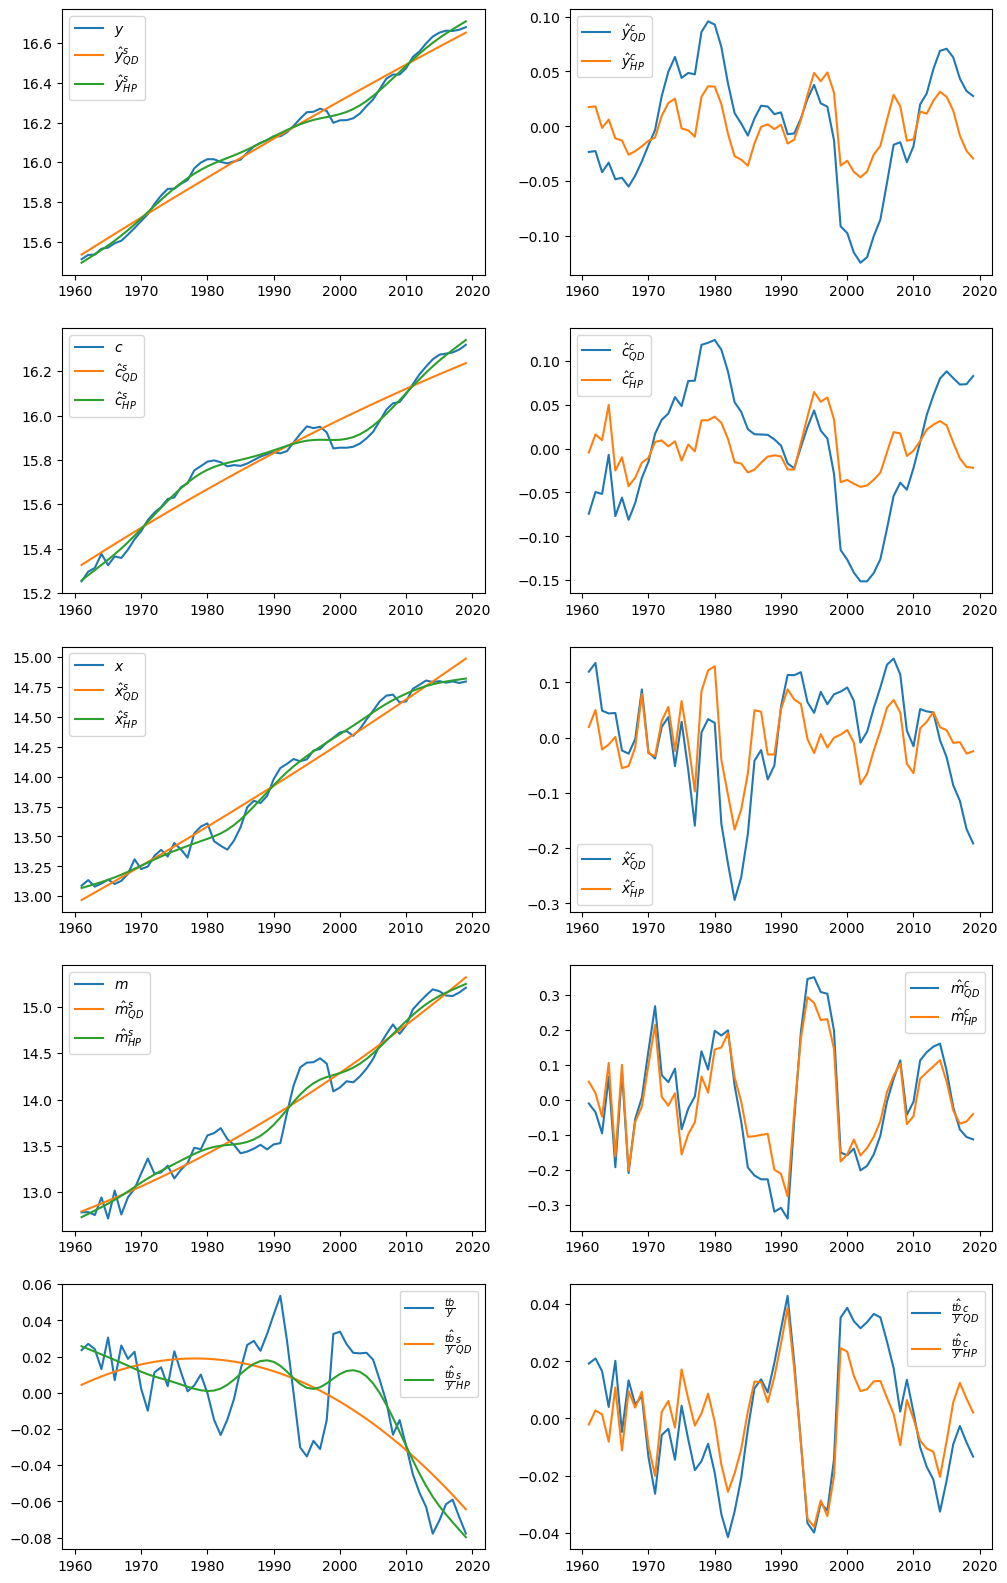

In [9]:
country_name = 'Colombia'

vars_subplot1 = ['NY.GDP.PCAP.KN', 'NY.GDP.PCAP.KN.S_QD', 'NY.GDP.PCAP.KN.S_HP']
vars_subplot2 = ['NY.GDP.PCAP.KN.C_QD', 'NY.GDP.PCAP.KN.C_HP']
vars_subplot3 = ['CON.PRVT.KN.PC', 'CON.PRVT.KN.PC.S_QD', 'CON.PRVT.KN.PC.S_HP']
vars_subplot4 = ['CON.PRVT.KN.PC.C_QD', 'CON.PRVT.KN.PC.C_HP']
vars_subplot5 = ['EXP.GNFS.KN.PC', 'EXP.GNFS.KN.PC.S_QD', 'EXP.GNFS.KN.PC.S_HP']
vars_subplot6 = ['EXP.GNFS.KN.PC.C_QD', 'EXP.GNFS.KN.PC.C_HP']
vars_subplot7 = ['IMP.GNFS.KN.PC', 'IMP.GNFS.KN.PC.S_QD', 'IMP.GNFS.KN.PC.S_HP']
vars_subplot8 = ['IMP.GNFS.KN.PC.C_QD', 'IMP.GNFS.KN.PC.C_HP']
vars_subplot9 = ['TB.KN.PC.TO.GDP', 'TB.KN.PC.TO.GDP.S_QD', 'TB.KN.PC.TO.GDP.S_HP']
vars_subplot10 = ['TB.KN.PC.TO.GDP.C_QD', 'TB.KN.PC.TO.GDP.C_HP']

labels_subplot1 = [r'$y$', r'$\hat{y}_{QD}^{s}$', r'$\hat{y}_{HP}^{s}$']
labels_subplot2 = [r'$\hat{y}_{QD}^{c}$', r'$\hat{y}_{HP}^{c}$']
labels_subplot3 = [r'$c$', r'$\hat{c}_{QD}^{s}$', r'$\hat{c}_{HP}^{s}$']
labels_subplot4 = [r'$\hat{c}_{QD}^{c}$', r'$\hat{c}_{HP}^{c}$']
labels_subplot5 = [r'$x$', r'$\hat{x}_{QD}^{s}$', r'$\hat{x}_{HP}^{s}$']
labels_subplot6 = [r'$\hat{x}_{QD}^{c}$', r'$\hat{x}_{HP}^{c}$']
labels_subplot7 = [r'$m$', r'$\hat{m}_{QD}^{s}$', r'$\hat{m}_{HP}^{s}$']
labels_subplot8 = [r'$\hat{m}_{QD}^{c}$', r'$\hat{m}_{HP}^{c}$']
labels_subplot9 = [r'$\frac{tb}{y}$', r'$\hat{\frac{tb}{y}}_{QD}^{s}$', r'$\hat{\frac{tb}{y}}_{HP}^{s}$']
labels_subplot10 = [r'$\hat{\frac{tb}{y}}_{QD}^{c}$', r'$\hat{\frac{tb}{y}}_{HP}^{c}$']

fig, axes = plt.subplots(nrows = 5, ncols = 2, figsize = (12, 20))

for variable, label in zip(vars_subplot1, labels_subplot1):
    axes[0, 0].plot(series_dict[country_name].index,
         series_dict[country_name][variable],
         label = label)
axes[0, 0].legend()

for variable, label in zip(vars_subplot2, labels_subplot2):
    axes[0, 1].plot(series_dict[country_name].index,
         series_dict[country_name][variable],
         label = label)
axes[0, 1].legend()

for variable, label in zip(vars_subplot3, labels_subplot3):
    axes[1, 0].plot(series_dict[country_name].index,
         series_dict[country_name][variable],
         label = label)
axes[1, 0].legend()

for variable, label in zip(vars_subplot4, labels_subplot4):
    axes[1, 1].plot(series_dict[country_name].index,
         series_dict[country_name][variable],
         label = label)
axes[1, 1].legend()

for variable, label in zip(vars_subplot5, labels_subplot5):
    axes[2, 0].plot(series_dict[country_name].index,
         series_dict[country_name][variable],
         label = label)
axes[2, 0].legend()

for variable, label in zip(vars_subplot6, labels_subplot6):
    axes[2, 1].plot(series_dict[country_name].index,
         series_dict[country_name][variable],
         label = label)
axes[2, 1].legend()

for variable, label in zip(vars_subplot7, labels_subplot7):
    axes[3, 0].plot(series_dict[country_name].index,
         series_dict[country_name][variable],
         label = label)
axes[3, 0].legend()

for variable, label in zip(vars_subplot8, labels_subplot8):
    axes[3, 1].plot(series_dict[country_name].index,
         series_dict[country_name][variable],
         label = label)
axes[3, 1].legend()

for variable, label in zip(vars_subplot9, labels_subplot9):
    axes[4, 0].plot(series_dict[country_name].index,
         series_dict[country_name][variable],
         label = label)
axes[4, 0].legend()

for variable, label in zip(vars_subplot10, labels_subplot10):
    axes[4, 1].plot(series_dict[country_name].index,
         series_dict[country_name][variable],
         label = label)
axes[4, 1].legend()

Following Schmitt-Grohe and Uribe (2017, Ch.1), the business cycle analysis will be based on the estimation of 3 statistical moments of the estimated cyclical component $(\hat{z}^{c})$: 

- the *standard deviation* $(\sigma_{z^{c}})$,
- the *serial correlation* (first order): $\hat{\rho}\leftarrow z_{t}^{c} = \rho z_{t-1}^{c} + \varepsilon_{t}$
- the correlation with (cyclical) GDP per capita $(\rho_{z^{c}y^{c}})$

To compute these moments from our estimated cyclical components, we need to discriminate by the methodological approach used to decompose the original series. With this purpose, we first create two *lists* each containing the cyclical components estimated using the *quadratic detrending* (`cycle_vars_QD`) approach and the *Hodrick-Prescott filter* (`cycle_vars_HP`). Within a loop structure by country, we compute the standard deviations and the serial correlation of these cyclical components the DataFrame attribute functions `std()` y `autocorr(lag = 1)`. To compute the correlation with the GDP per capita, we first use the DataFrame attribute function `corr()` to compute the complete correlation matrix of the cyclical components of all variables, then, discriminating by the decomposition methodological approach, we make sure to extract the right correlation with respect either to $\hat{y}_{QD}^{c}$, in the case of the remaining $\hat{z}_{QD}^{c}$, (`corr_matrix[cycle_vars_QD[0]]`) or to $\hat{y}_{HP}^{c}$, in the case of the remaining $\hat{z}_{HP}^{c}$ (`corr_matrix[cycle_vars_HP[0]]`):

In [10]:
cycle_vars_QD = ['NY.GDP.PCAP.KN.C_QD', 'CON.PRVT.KN.PC.C_QD',
                 'EXP.GNFS.KN.PC.C_QD', 'IMP.GNFS.KN.PC.C_QD',
                 'TB.KN.PC.TO.GDP.C_QD']

cycle_vars_HP = ['NY.GDP.PCAP.KN.C_HP', 'CON.PRVT.KN.PC.C_HP',
                 'EXP.GNFS.KN.PC.C_HP', 'IMP.GNFS.KN.PC.C_HP',
                 'TB.KN.PC.TO.GDP.C_HP']

cycle_variables = cycle_vars_QD + cycle_vars_HP

bc_stats_dict = {}

for country in countries:
    bc_stats_dict[country] = pd.DataFrame(index = cycle_variables)
    
    bc_stats_dict[country]['Standard deviations'] = series_dict[country].std()
    
    bc_stats_dict[country]['Serial correlation'] = np.nan
    for variable in cycle_variables:
        bc_stats_dict[country].loc[variable, 'Serial correlation'] = series_dict[country][variable].autocorr(lag = 1)
            
    corr_matrix = series_dict[country][cycle_variables].corr()
    bc_stats_dict[country]['Correlation with output'] = np.nan
    bc_stats_dict[country].loc[cycle_vars_QD, 'Correlation with output'] = corr_matrix[cycle_vars_QD[0]]    
    bc_stats_dict[country].loc[cycle_vars_HP, 'Correlation with output'] = corr_matrix[cycle_vars_HP[0]]
    
bc_stats_dict['Colombia']

,Standard deviations,Serial correlation,Correlation with output
NY.GDP.PCAP.KN.C_QD,0.053903,0.931003,1.000000
CON.PRVT.KN.PC.C_QD,0.073973,0.942918,0.968653
EXP.GNFS.KN.PC.C_QD,0.101199,0.799397,-0.322573
IMP.GNFS.KN.PC.C_QD,0.170526,0.739996,0.449418
TB.KN.PC.TO.GDP.C_QD,0.022743,0.811126,-0.723370
NY.GDP.PCAP.KN.C_HP,0.024291,0.752580,1.000000
CON.PRVT.KN.PC.C_HP,0.027208,0.705763,0.911121
EXP.GNFS.KN.PC.C_HP,0.058153,0.476141,0.453451
IMP.GNFS.KN.PC.C_HP,0.131242,0.612650,0.666970
TB.KN.PC.TO.GDP.C_HP,0.015653,0.656271,-0.545265


### Business Cycle Facts

Using a sample of 120 countries in the period from 1965 to 2010 and data from the WDI, Schmitt-Grohe and Uribe (2017, Ch.1) used the secular trend-cycle decomposition approaches shown in the previous section and computed the statistical moments listed above to perform an analysis of the business cycle. They listed a set of *Business-Cycle Facts* based on the analysis of these moments. Some of the most important facts for us are:

#### High Global Volatility

*The cross-country average standard deviation of output is twice as large as its U.S. counterpart.*

#### Excess Consumption Volatility

*On average across countries, private consumption including durables is more volatile than output.*

#### Excess Volatility of Poor and Emerging Countries

*Business cycles in rich countries are about half as volatile as business cycles in emerging or poor countries.*

#### Less Consumption Smoothing in Poor and Emerging Countries

*The relative consumption volatility is higher in poor and emerging countries than in rich countries.*

Let's give some light to these facts by checking the estimated standard deviations summarised in a single table. We start first with those associated to the quadratic detrending approach:

In [11]:
volatility_table_QD = pd.DataFrame(index = poor_countries + em_countries 
                                + rich_countries,
                                columns = ['sigma_y_QD_c', 'sigma_c_QD_c', 'sigma_x_QD_c',
                                'sigma_m_QD_c', 'sigma_tby_QD_c'])

countries = volatility_table_QD.index
moments_QD = volatility_table_QD.columns

for country in countries:
    for moment, variable in zip(moments_QD, cycle_vars_QD):
        volatility_table_QD.loc[country, moment] = bc_stats_dict[country].loc[(variable, 'Standard deviations')]
        
volatility_table_QD

,sigma_y_QD_c,sigma_c_QD_c,sigma_x_QD_c,sigma_m_QD_c,sigma_tby_QD_c
Cameroon,0.155135,0.119014,0.185235,0.174887,0.026267
India,0.023697,0.023365,0.174784,0.1974,0.013648
Brazil,0.101845,0.120161,0.316127,0.41665,0.024805
Colombia,0.053903,0.073973,0.101199,0.170526,0.022743
United Kingdom,0.040441,0.052798,0.078269,0.089859,0.008698
United States,0.026802,0.029668,0.085234,0.117007,0.010093


Now, we do the same but with the estimated standard deviations from the cyclical components obtained using the Hodrick-Prescott filter:

In [12]:
volatility_table_HP = pd.DataFrame(index = poor_countries + em_countries 
                                + rich_countries,
                                columns = ['sigma_y_HP_c', 'sigma_c_HP_c', 'sigma_x_HP_c',
                                'sigma_m_HP_c', 'sigma_tby_HP_c'])

moments_HP = volatility_table_HP.columns

for country in countries:
    for moment, variable in zip(moments_HP, cycle_vars_HP):
        volatility_table_HP.loc[country, moment] = bc_stats_dict[country].loc[(variable, 'Standard deviations')]
        
volatility_table_HP

,sigma_y_HP_c,sigma_c_HP_c,sigma_x_HP_c,sigma_m_HP_c,sigma_tby_HP_c
Cameroon,0.051181,0.06578,0.101218,0.129493,0.015366
India,0.020538,0.015268,0.070165,0.096879,0.010521
Brazil,0.038844,0.051,0.161477,0.187929,0.013969
Colombia,0.024291,0.027208,0.058153,0.131242,0.015653
United Kingdom,0.02284,0.025404,0.035023,0.044208,0.006659
United States,0.019406,0.018821,0.054851,0.060971,0.005799


Regarding the serial correlation, another important business-cycle fact is:

#### Persistence

*The components of aggregate supply (output and imports) and aggregate demand (consumption, government spending, investment, and exports) are all positive serially correlated.*

To check for this fact in our data, we can build tables with the values of the serial correlations of each of the cyclical components estimated using the two aforementioned detrending approaches. Let's start with those coming from quadratic detrending:

In [13]:
persistence_table_QD = pd.DataFrame(index = poor_countries + em_countries 
                                + rich_countries,
                                columns = ['rho_y_QD_c', 'rho_c_QD_c', 'rho_x_QD_c',
                                'rho_m_QD_c', 'rho_tby_QD_c'])

persistences_QD = persistence_table_QD.columns

for country in countries:
    for moment, variable in zip(persistences_QD, cycle_vars_QD):
        persistence_table_QD.loc[country, moment] = bc_stats_dict[country].loc[(variable, 'Serial correlation')]
        
persistence_table_QD

,rho_y_QD_c,rho_c_QD_c,rho_x_QD_c,rho_m_QD_c,rho_tby_QD_c
Cameroon,0.941317,0.811038,0.790093,0.73719,0.713282
India,0.384067,0.640035,0.86815,0.844371,0.702154
Brazil,0.940769,0.884964,0.853644,0.917381,0.866457
Colombia,0.931003,0.942918,0.799397,0.739996,0.811126
United Kingdom,0.866849,0.911416,0.8734,0.880853,0.73573
United States,0.762521,0.858663,0.815241,0.850512,0.899862


Now, those coming from using the Hodrick-Prescott filter:

In [14]:
persistence_table_HP = pd.DataFrame(index = poor_countries + em_countries 
                                + rich_countries,
                                columns = ['rho_y_HP_c', 'rho_c_HP_c', 'rho_x_HP_c',
                                'rho_m_HP_c', 'rho_tby_HP_c'])

persistences_HP = persistence_table_HP.columns

for country in countries:
    for moment, variable in zip(persistences_HP, cycle_vars_HP):
        persistence_table_HP.loc[country, moment] = bc_stats_dict[country].loc[(variable, 'Serial correlation')]
        
persistence_table_HP

,rho_y_HP_c,rho_c_HP_c,rho_x_HP_c,rho_m_HP_c,rho_tby_HP_c
Cameroon,0.66574,0.459936,0.414681,0.579365,0.246806
India,0.24372,0.222237,0.383351,0.487452,0.533994
Brazil,0.722206,0.467591,0.499932,0.689001,0.668641
Colombia,0.75258,0.705763,0.476141,0.61265,0.656271
United Kingdom,0.645392,0.703942,0.459754,0.582529,0.59634
United States,0.591578,0.707001,0.616246,0.529253,0.78232


Finally, some business-cycle facts regarding the correlation with output:

#### Procyclicality of the Components of Aggregate Demand

*On average, consumption, investment, exports, and imports are all positively correlated with output.*

#### Countercyclicality of the Trade Balance and the Current Account

*On average across countries, the trade balance, trade-balance-to-output ratio, current account, and current-account-to output ratio are all negatively correlated with output.*

It is also possible to summarise by country the correlations to output estimated for each variable of interest given the detrending methodology used. Let's start with quadratic detrending:

In [15]:
cyclicality_table_QD = pd.DataFrame(index = poor_countries + em_countries 
                                + rich_countries,
                                columns = ['rho_cy_QD_c', 'rho_xy_QD_c',
                                'rho_my_QD_c', 'rho_tbyy_QD_c'])

correlations_QD = cyclicality_table_QD.columns

for country in countries:
    for moment, variable in zip(correlations_QD, cycle_vars_QD[+1:]):
        cyclicality_table_QD.loc[country, moment] = bc_stats_dict[country].loc[(variable, 'Correlation with output')]
        
cyclicality_table_QD

,rho_cy_QD_c,rho_xy_QD_c,rho_my_QD_c,rho_tbyy_QD_c
Cameroon,0.875886,0.601326,0.155739,0.098478
India,0.397074,0.166819,0.053942,-0.025052
Brazil,0.896137,0.781449,0.799804,-0.405798
Colombia,0.968653,-0.322573,0.449418,-0.72337
United Kingdom,0.967938,0.736985,0.954487,-0.427899
United States,0.932922,0.296992,0.851145,-0.720063


And now with those estimated from the cyclical components obtained from using the Hodrick-Prescott filter:

In [16]:
cyclicality_table_HP = pd.DataFrame(index = poor_countries + em_countries 
                                + rich_countries,
                                columns = ['rho_cy_HP_c', 'rho_xy_HP_c',
                                'rho_my_HP_c', 'rho_tbyy_HP_c'])

correlations_HP = cyclicality_table_HP.columns

for country in countries:
    for moment, variable in zip(correlations_HP, cycle_vars_HP[+1:]):
        cyclicality_table_HP.loc[country, moment] = bc_stats_dict[country].loc[(variable, 'Correlation with output')]
        
cyclicality_table_HP

,rho_cy_HP_c,rho_xy_HP_c,rho_my_HP_c,rho_tbyy_HP_c
Cameroon,0.764621,0.366836,0.401011,-0.176508
India,0.736551,0.093203,-0.018618,0.003564
Brazil,0.644918,0.22053,0.610036,-0.609757
Colombia,0.911121,0.453451,0.66697,-0.545265
United Kingdom,0.92838,0.53771,0.903203,-0.513752
United States,0.918712,0.246366,0.876457,-0.593917
